## Throughput

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/nr_4/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_8/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_16/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/nr_32/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_48/tsm-sc-001/node2/stellar-core.log']


throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # # ---- Plot Throughput ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    # plt.xlabel("Time (s)")
    # plt.ylabel("Transactions/sec")
    # plt.ylim(0, throughput.values.max() * 1.2)
    # plt.title("Throughput vs Time (Normal Consensus Only)")
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("throughput.png", dpi=150)
    # plt.show()
    
    # # ---- Plot Latency ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    # plt.xlabel("Time (s)")
    # plt.ylabel("Latency (s)")
    # plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("latency.png", dpi=150)
    # plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

# Collection Plots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/collection_100_rounds_4/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_100_rounds_8/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_100_rounds_16/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_100_rounds_32/tsm-sc-001/node2/stellar-core.log']

throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        # if view in collect_views:
        #     continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # ---- Plot Throughput ----
    plt.figure(figsize=(10, 4))
    plt.plot(throughput.index[10:], throughput.values[10:], "-", label="Throughput (txns/sec)")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.ylim(0, throughput.values.max() * 1.2)
    plt.title("Throughput vs Time (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()
    
    # ---- Plot Latency ----
    plt.figure(figsize=(10, 4))
    plt.plot(latency_series.index[10:], latency_series.values[10:], "-", color="r", label="Latency (s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("latency.png", dpi=150)
    plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

In [ ]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.15,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



node_list = [4,8, 16, 32, 48]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    plt.plot(
        throughput_ma.index[:150],
        throughput_ma.values[:150],
        "-",
        label=f"{node_list[i]} nodes"
    )

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — OORUBC")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/collect_vs_nodes_thput.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index[:150],
        latency_ma.values[:150],
        "-",
        label=f"{node_list[i]} nodes"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — OORUBC")
# plt.title("Proposal to Commit Latency (During Collection)")


plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)

plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/collect_vs_nodes_lat.pdf", dpi=150)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/collection_1_rounds_16/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_10_rounds_16/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_50_rounds_16/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_100_rounds_16/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_200_rounds_16/tsm-sc-001/node2/stellar-core.log']

throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        # if view in collect_views:
        #     continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # ---- Plot Throughput ----
    plt.figure(figsize=(10, 4))
    plt.plot(throughput.index[10:], throughput.values[10:], "-", label="Throughput (txns/sec)")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.ylim(0, throughput.values.max() * 1.2)
    plt.title("Throughput vs Time (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()
    
    # ---- Plot Latency ----
    plt.figure(figsize=(10, 4))
    plt.plot(latency_series.index[10:], latency_series.values[10:], "-", color="r", label="Latency (s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("latency.png", dpi=150)
    plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

In [ ]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.10,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



round_list = [1,10, 50, 100, 200]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    plt.plot(
        throughput_ma.index[:150],
        throughput_ma.values[:150],
        "-",
        label=f"{round_list[i]} cr"
    )

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — OORUBC")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/thput_vs_collect_rounds.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index[:150],
        latency_ma.values[:150],
        "-",
        label=f"{round_list[i]} cr"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — OORUBC")
# plt.title("Proposal to Commit Latency (During Collection)")


plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)

plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/lat_vs_collect_rounds.pdf", dpi=150)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/collection_100_rounds_16/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_100_rounds_16_zone_0/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_100_rounds_16_zone_1/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_100_rounds_16_zone_2/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_100_rounds_16_zone_3/tsm-sc-001/node2/stellar-core.log']

throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        # if view in collect_views:
        #     continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # ---- Plot Throughput ----
    plt.figure(figsize=(10, 4))
    plt.plot(throughput.index[10:], throughput.values[10:], "-", label="Throughput (txns/sec)")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.ylim(0, throughput.values.max() * 1.2)
    plt.title("Throughput vs Time (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()
    
    # ---- Plot Latency ----
    plt.figure(figsize=(10, 4))
    plt.plot(latency_series.index[10:], latency_series.values[10:], "-", color="r", label="Latency (s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("latency.png", dpi=150)
    plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

In [ ]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.10,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



nl_list = [0,52,91,148, 214]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    print(np.nanmean(np.array(throughput_ma.values[:150])))
    plt.plot(
        throughput_ma.index[:150],
        throughput_ma.values[:150]/ np.nanmean(np.array(throughput_ma.values[:150])),
        "-",
        label=f"NL={nl_list[i]} (normalized)"
    )

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — OORUBC")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/thput_vs_NL.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index[:150],
        latency_ma.values[:150]/np.nanmean(np.array(latency_ma.values[:150])),
        "-",
        label=f"NL={nl_list[i]} (normalized)"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — OORUBC")
# plt.title("Proposal to Commit Latency (During Collection)")


plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)

plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/lat_vs_NL.pdf", dpi=150)
plt.show()


# Memory Plots

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

log_file_list = [
    # '../work/experiments/stellar-core/memory_4_no_cleanup/tsm-sc-001/node2/stellar-core.log',
    '../work/experiments/stellar-core/memory_4_regular_cleanup/tsm-sc-001/node2/stellar-core.log',
    '../work/experiments/stellar-core/memory_4_test/tsm-sc-001/node2/stellar-core.log'
]

memory_series_list = []
elements_series_list = []

# Updated regex: RSS + element count
memory_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*MEMORY RSS:\s+(\d+)\s+MB,\s+number of elements:\s+(\d+)"
)

for log_file in log_file_list:
    print(f"Processing: {log_file}")

    timestamps = []
    memory_mb = []
    elements = []

    with open(log_file) as f:
        for line in f:
            match = memory_pattern.search(line)
            if match:
                ts = datetime.strptime(match.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                mem = int(match.group(2))
                elems = int(match.group(3))

                timestamps.append(ts)
                memory_mb.append(mem)
                elements.append(elems)

    if not timestamps:
        print("⚠️ No memory entries found")
        continue

    # Normalize time
    start_time = min(timestamps)
    time_sec = [(t - start_time).total_seconds() for t in timestamps]

    df = pd.DataFrame({
        "time_sec": time_sec,
        "memory_mb": memory_mb,
        "elements": elements
    }).set_index("time_sec")

    # Aggregate per second
    df = df.groupby(df.index.round()).mean()

    # Fill missing seconds
    full_index = np.arange(
        int(np.floor(df.index.min())),
        int(np.ceil(df.index.max())) + 1
    )
    df = df.reindex(full_index).interpolate()

    memory_series_list.append(df["memory_mb"])
    elements_series_list.append(df["elements"])

    print("Average RSS (MB):", np.mean(df["memory_mb"].values[-90:-30]))


Processing: ../work/experiments/stellar-core/memory_4_regular_cleanup/tsm-sc-001/node2/stellar-core.log
Average RSS (MB): 75.59588961150175
Processing: ../work/experiments/stellar-core/memory_4_test/tsm-sc-001/node2/stellar-core.log
Average RSS (MB): 42.906704445347785


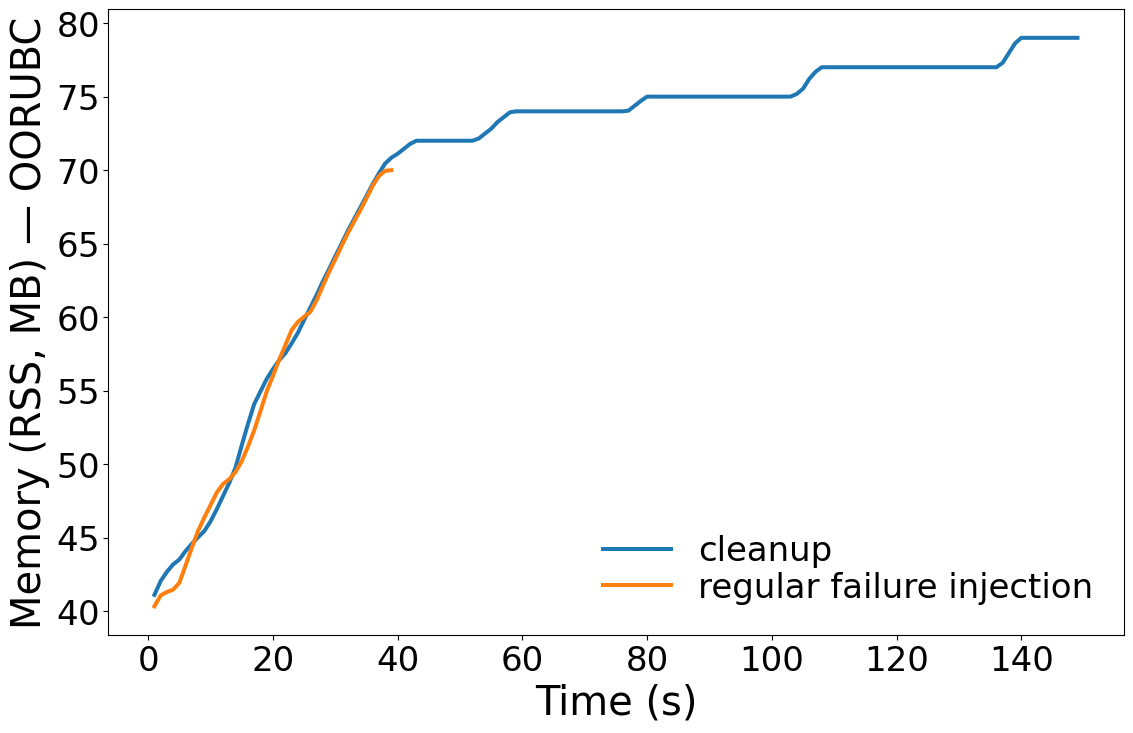

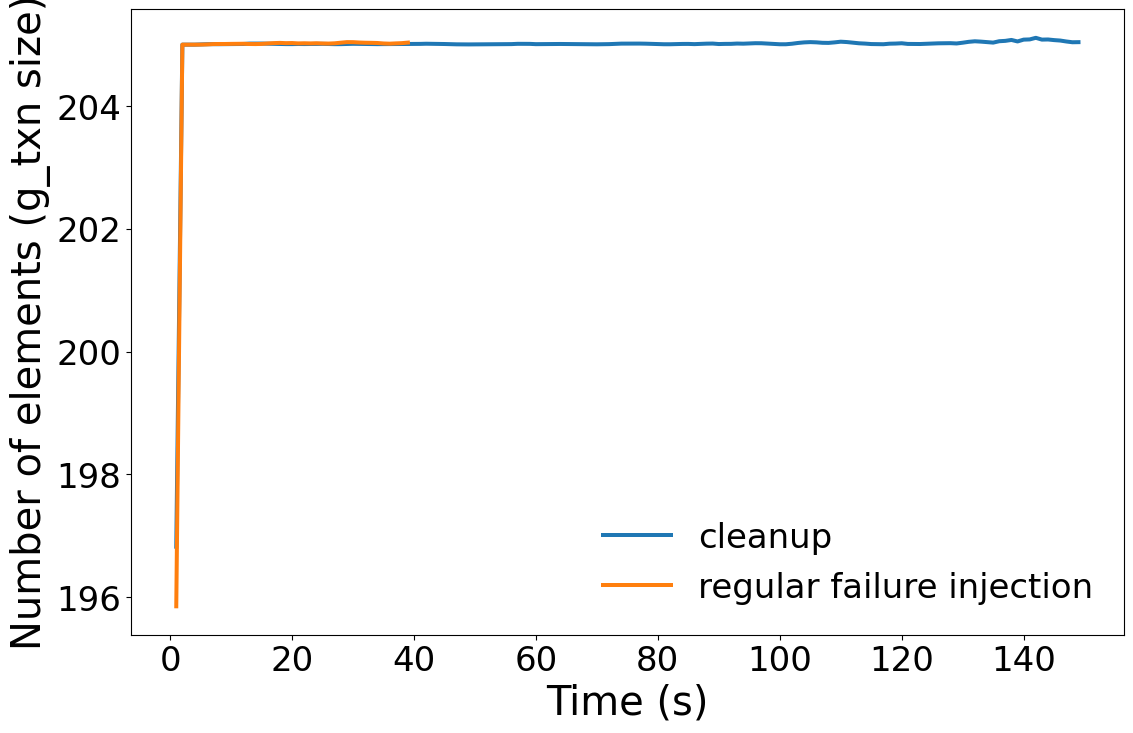

In [10]:
    


import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt
    base = 0.05 * height_pt

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.10,
    }


# -----------------------------
# Global style
# -----------------------------
fig_w, fig_h = 12, 8  # inches
mpl.rcParams.update(font_scale_from_figsize(fig_w, fig_h))

# label_list = ['no cleanup', 'cleanup', 'regular failure injection']
label_list = ['cleanup',  'regular failure injection']

window = 3  # moving average window

# -----------------------------
# Plot Memory
# -----------------------------
plt.figure(figsize=(12, 8))

for i, mem_series in enumerate(memory_series_list):
    mem_ma = mem_series.rolling(window=window, center=True).mean()

    plt.plot(
        mem_ma.index[:150],
        mem_ma.values[:150],
        "-",
        label=f"{label_list[i]}"
    )

plt.xlabel("Time (s)")
plt.ylabel("Memory (RSS, MB) — OORUBC")

plt.legend(labelspacing=0.1, frameon=False)

# Force plain numeric ticks (no scientific notation)
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.savefig(
    "../work/Stellar2/Figures/memory.pdf",
    dpi=150
)
plt.show()



plt.figure(figsize=(12, 8))

for i, elem_series in enumerate(elements_series_list):
    elem_ma = elem_series.rolling(window=window, center=True).mean()
    plt.plot(elem_ma.index[:150], elem_ma.values[:150], label=label_list[i])

plt.xlabel("Time (s)")
plt.ylabel("Number of elements (g_txn size)")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/memory_elements.pdf", dpi=150)
plt.show()

In [5]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import re
# from datetime import datetime
# import numpy as np

# # Path to your log files (same structure as throughput script)
# log_file_list = [
#     '../stellar-privateTraingle/node2/stellar-core.log',\
#     '../stellar-private/node2/stellar-core.log'
# ]

# memory_series_list = []

# # Regex for memory log
# memory_pattern = re.compile(
#     r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*MEMORY RSS:\s+(\d+)\s+MB"
# )

# for log_file in log_file_list:
#     print(f"Processing: {log_file}")

#     timestamps = []
#     memory_mb = []

#     with open(log_file) as f:
#         for line in f:
#             # print()
#             match = memory_pattern.search(line)
#             if match:
#                 ts = datetime.strptime(match.group(1), "%Y-%m-%dT%H:%M:%S.%f")
#                 mem = int(match.group(2))
#                 timestamps.append(ts)
#                 memory_mb.append(mem)

#     if not timestamps:
#         print("⚠️ No memory entries found")
#         continue

#     # Normalize time to seconds since first memory log
#     start_time = min(timestamps)
#     time_sec = [(t - start_time).total_seconds() for t in timestamps]

#     df = pd.DataFrame({
#         "time_sec": time_sec,
#         "memory_mb": memory_mb
#     })

#     df.set_index("time_sec", inplace=True)

#     # Aggregate per second (mean RSS per second)
#     mem_series = df.groupby(df.index.round()).mean()["memory_mb"]

#     # Fill missing integer seconds
#     full_index = np.arange(
#         int(np.floor(mem_series.index.min())),
#         int(np.ceil(mem_series.index.max())) + 1
#     )
#     mem_series = mem_series.reindex(full_index, fill_value=np.nan)
#     mem_series = mem_series.interpolate()  # smooth gaps

#     memory_series_list.append(mem_series)

#     print("Average Memory (MB):",
#           np.mean(mem_series.values[-90:-30]))



    


Processing: ../stellar-privateTraingle/node2/stellar-core.log
Average Memory (MB): 83.60714285714286
Processing: ../stellar-private/node2/stellar-core.log
Average Memory (MB): 61.0


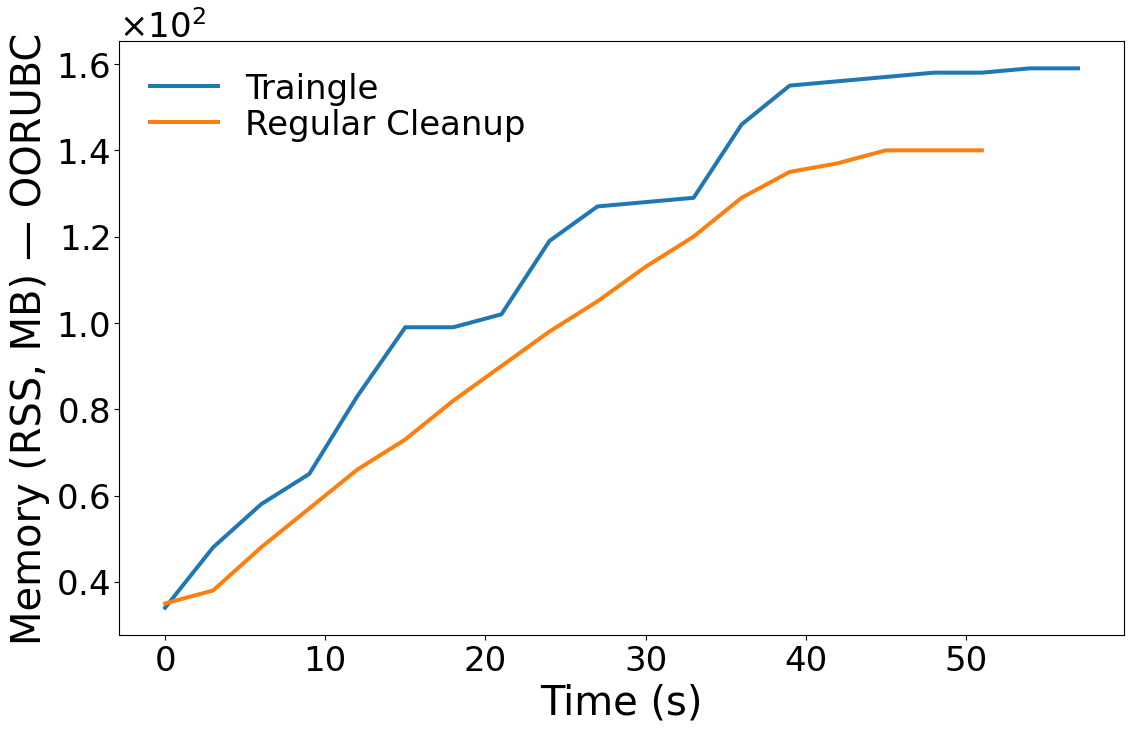

In [6]:
# import pylab as pl
# import matplotlib as mpl
# from matplotlib.ticker import ScalarFormatter
# import numpy as np
# from matplotlib.ticker import FuncFormatter


# def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
#     """
#     Returns a dict of font sizes scaled to figure size.
#     """
#     height_pt = fig_height_in * 72  # 1 inch = 72 pt
#     base = 0.05 * height_pt

#     return {
#         "font.size": base,
#         "axes.labelsize": base * 1.0,
#         "xtick.labelsize": base * 0.85,
#         "ytick.labelsize": base * 0.85,
#         "legend.fontsize": base * 0.85,
#         "axes.titlesize": base * 1.05,
#         "lines.markersize": base * 0.55,
#         "lines.linewidth": base * 0.10,
#     }


# # -----------------------------
# # Global style
# # -----------------------------
# fig_w, fig_h = 12, 8  # inches
# mpl.rcParams.update(font_scale_from_figsize(fig_w, fig_h))

# label_list = ['Traingle', 'Regular Cleanup']
# window = 1  # moving average window

# # -----------------------------
# # Plot Memory
# # -----------------------------
# plt.figure(figsize=(12, 8))

# for i, mem_series in enumerate(memory_series_list):
#     mem_ma = mem_series.rolling(window=window, center=True).mean()

#     plt.plot(
#         mem_ma.index,
#         mem_ma.values,
#         "-",
#         label=f"{label_list[i]}"
#     )

# plt.xlabel("Time (s)")
# plt.ylabel("Memory (RSS, MB) — OORUBC")

# plt.legend(labelspacing=0.1, frameon=False)

# # Force plain numeric ticks (no scientific notation)
# formatter = ScalarFormatter(useMathText=True)
# formatter.set_powerlimits((-2, 2))
# plt.gca().yaxis.set_major_formatter(formatter)

# plt.tight_layout()

# plt.show()
